In [92]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data bài 1

In [93]:
import json, torch
import pandas as pd
from collections import Counter
from torch.utils.data import Dataset, DataLoader

train_df = pd.read_json("/content/drive/MyDrive/DL-TH5/data/UIT-ViOCD/train.json").T
dev_df   = pd.read_json("/content/drive/MyDrive/DL-TH5/data/UIT-ViOCD/dev.json").T
test_df  = pd.read_json("/content/drive/MyDrive/DL-TH5/data/UIT-ViOCD/test.json").T

## Tokenizer & Vocab

In [94]:
def tokenize(text):
    return text.lower().split()

counter = Counter()
for s in train_df.review:
    counter.update(tokenize(s))

PAD, UNK = "<pad>", "<unk>"
vocab = {PAD:0, UNK:1}
for w,_ in counter.items():
    vocab[w] = len(vocab)

label2id = {l:i for i,l in enumerate(train_df.label.unique())}
domain2id = {d:i for i,d in enumerate(train_df.domain.unique())}

## Dataset

In [95]:
class ClsDataset(Dataset):
    def __init__(self, df, max_len=64):
        self.df = df
        self.max_len = max_len

    def __getitem__(self, idx):
        tokens = tokenize(self.df.iloc[idx].review)[:self.max_len]
        ids = [vocab.get(t,1) for t in tokens]
        ids += [0]*(self.max_len-len(ids))
        return torch.tensor(ids), torch.tensor(label2id[self.df.iloc[idx].label])

    def __len__(self):
        return len(self.df)

# Data bài 2

In [96]:
def read_conll(path):
    sents, labels = [], []
    words, tags = [], []
    with open(path) as f:
        for line in f:
            line=line.strip()
            if not line:
                sents.append(words)
                labels.append(tags)
                words, tags = [], []
            else:
                w,t = line.split()
                words.append(w.lower())
                tags.append(t)
    return sents, labels

In [97]:
train_s, train_l = read_conll("/content/drive/MyDrive/DL-TH5/data/PHONER/train_word.conll")
dev_s, dev_l     = read_conll("/content/drive/MyDrive/DL-TH5/data/PHONER/dev_word.conll")
test_s, test_l   = read_conll("/content/drive/MyDrive/DL-TH5/data/PHONER/test_word.conll")

## Build vocab & label map

In [98]:
counter = Counter(w for s in train_s for w in s)
vocab = {PAD:0, UNK:1}
for w,_ in counter.items():
    vocab[w] = len(vocab)

tag2id = {t:i for i,t in enumerate(set(t for l in train_l for t in l))}

# attention.py

In [99]:
%%writefile "/content/drive/MyDrive/DL-TH5/attention.py"
import torch
from torch import nn
import math

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads, dropout):
        super().__init__()
        assert d_model % heads == 0
        self.d_k = d_model // heads
        self.h = heads

        self.qkv = nn.Linear(d_model, d_model*3)
        self.fc = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B, T, C = x.size()
        qkv = self.qkv(x).chunk(3, dim=-1)
        q, k, v = [t.view(B, T, self.h, self.d_k).transpose(1,2) for t in qkv]

        scores = (q @ k.transpose(-2,-1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        att = torch.softmax(scores, dim=-1)
        out = (att @ v).transpose(1,2).contiguous().view(B,T,C)
        return self.fc(out)

Overwriting /content/drive/MyDrive/DL-TH5/attention.py


# transformer.py

In [100]:
%%writefile "/content/drive/MyDrive/DL-TH5/transformer.py"
import torch
from torch import nn
from attention import MultiHeadAttention
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0,d_model,2)*(-math.log(10000)/d_model))
        pe[:,0::2] = torch.sin(pos*div)
        pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:,:x.size(1)]

class EncoderLayer(nn.Module):
    def __init__(self, d_model, heads, d_ff, dropout):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, heads, dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask):
        x = self.norm1(x + self.drop(self.attn(x, mask)))
        x = self.norm2(x + self.drop(self.ff(x)))
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, layers, d_model, heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, heads, d_ff, dropout)
            for _ in range(layers)
        ])

    def forward(self, x, mask):
        for l in self.layers:
            x = l(x, mask)
        return x

Overwriting /content/drive/MyDrive/DL-TH5/transformer.py


# classification.py

In [101]:
%%writefile "/content/drive/MyDrive/DL-TH5/classification.py"
import torch
from torch import nn
from transformer import TransformerEncoder, PositionalEncoding

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, n_labels, d_model=128):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pe = PositionalEncoding(d_model)
        self.encoder = TransformerEncoder(3, d_model, 4, 256, 0.1)
        self.fc = nn.Linear(d_model, n_labels)

    def forward(self, x):
        mask = (x != 0).unsqueeze(1).unsqueeze(2)
        x = self.pe(self.embed(x))
        x = self.encoder(x, mask)
        return self.fc(x[:,0])

Overwriting /content/drive/MyDrive/DL-TH5/classification.py


# sequential_labeling.py

In [102]:
%%writefile "/content/drive/MyDrive/DL-TH5/sequential_labeling.py"
import torch
from torch import nn
from transformer import TransformerEncoder, PositionalEncoding

class TransformerNER(nn.Module):
    def __init__(self, vocab_size, n_tags, d_model=128):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pe = PositionalEncoding(d_model)
        self.encoder = TransformerEncoder(3, d_model, 4, 256, 0.1)
        self.fc = nn.Linear(d_model, n_tags)

    def forward(self, x):
        mask = (x != 0).unsqueeze(1).unsqueeze(2)
        x = self.pe(self.embed(x))
        x = self.encoder(x, mask)
        return self.fc(x)

Overwriting /content/drive/MyDrive/DL-TH5/sequential_labeling.py


# Train bài 1

In [103]:
%%writefile "/content/drive/MyDrive/DL-TH5/assignment1.py"
import torch
from classification import TransformerClassifier
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

def train(model, loader, opt, loss_fn, device):
    model.train()
    total = 0
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        opt.step()
        total += loss.item()
    return total / len(loader)

Overwriting /content/drive/MyDrive/DL-TH5/assignment1.py


In [106]:
import sys
sys.path.insert(0, "/content/drive/MyDrive/DL-TH5")
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score

from classification import TransformerClassifier
from assignment1 import train

train_loader = DataLoader(
    ClsDataset(train_df),
    batch_size=32,
    shuffle=True
)

dev_loader = DataLoader(
    ClsDataset(dev_df),
    batch_size=32
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerClassifier(len(vocab), len(label2id)).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

train_losses = []
train_f1s = []

for epoch in range(10):
    model.train()
    total_loss = 0
    y_true, y_pred = [], []

    for x,y in train_loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad()

        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        opt.step()

        total_loss += loss.item()
        y_true.extend(y.cpu().numpy())
        y_pred.extend(logits.argmax(-1).cpu().numpy())

    avg_loss = total_loss / len(train_loader)
    f1 = f1_score(y_true, y_pred, average="macro")

    train_losses.append(avg_loss)
    train_f1s.append(f1)

    print(f"Epoch {epoch+1} | loss={avg_loss:.4f} | F1={f1:.4f}")

Epoch 1 | loss=0.6062 | F1=0.6870
Epoch 2 | loss=0.5265 | F1=0.7443
Epoch 3 | loss=0.5093 | F1=0.7591
Epoch 4 | loss=0.4771 | F1=0.7848
Epoch 5 | loss=0.4542 | F1=0.7895
Epoch 6 | loss=0.4287 | F1=0.8087
Epoch 7 | loss=0.4269 | F1=0.8076
Epoch 8 | loss=0.3815 | F1=0.8290
Epoch 9 | loss=0.3703 | F1=0.8338
Epoch 10 | loss=0.3606 | F1=0.8468


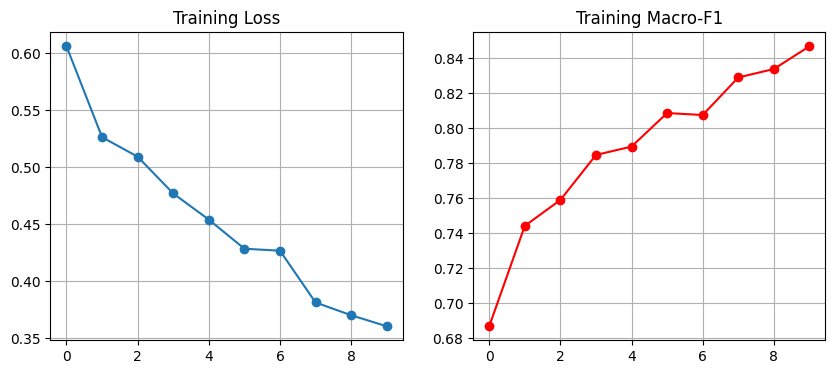

In [110]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.grid()

plt.subplot(1,2,2)
plt.plot(train_f1s, marker='o', color='red')
plt.title("Training Macro-F1")
plt.grid()
plt.show()

# Train bài 2

In [111]:
%%writefile "/content/drive/MyDrive/DL-TH5/assignment2.py"
import torch
from sequential_labeling import TransformerNER

def train(model, loader, opt, loss_fn):
    model.train()
    for x,y in loader:
        opt.zero_grad()
        logits = model(x)
        loss = loss_fn(logits.view(-1, logits.size(-1)), y.view(-1))
        loss.backward()
        opt.step()


Writing /content/drive/MyDrive/DL-TH5/assignment2.py


In [112]:
class NERDataset(Dataset):
    def __init__(self, sents, labels, max_len=64):
        self.sents = sents
        self.labels = labels
        self.max_len = max_len

    def __getitem__(self, idx):
        words = self.sents[idx][:self.max_len]
        tags  = self.labels[idx][:self.max_len]

        x = [vocab.get(w,1) for w in words]
        y = [tag2id[t] for t in tags]

        pad_len = self.max_len - len(x)
        x += [0]*pad_len
        y += [-100]*pad_len   # ignore_index

        return torch.tensor(x), torch.tensor(y)

    def __len__(self):
        return len(self.sents)

In [113]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    NERDataset(train_s, train_l),
    batch_size=16,
    shuffle=True
)

dev_loader = DataLoader(
    NERDataset(dev_s, dev_l),
    batch_size=16
)

In [114]:
import torch
from sequential_labeling import TransformerNER

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TransformerNER(
    vocab_size=len(vocab),
    n_tags=len(tag2id)
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loss_fn = torch.nn.CrossEntropyLoss(ignore_index=-100)

In [118]:
from sklearn.metrics import f1_score

losses = []
f1s = []

for epoch in range(10):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)

        loss = loss_fn(
            logits.view(-1, logits.size(-1)),
            y.view(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in dev_loader:
            x = x.to(device)
            logits = model(x)
            preds = logits.argmax(-1)

            y = y.view(-1).cpu().numpy()
            preds = preds.view(-1).cpu().numpy()

            mask = y != -100
            y_true.extend(y[mask])
            y_pred.extend(preds[mask])

    f1 = f1_score(y_true, y_pred, average="micro")
    f1s.append(f1)

    print(
        f"Epoch {epoch+1}/10 | "
        f"loss: {avg_loss:.4f} | "
        f"dev F1: {f1:.4f}"
    )

Epoch 1/10 | loss: 0.0475 | dev F1: 0.9307
Epoch 2/10 | loss: 0.0401 | dev F1: 0.9318
Epoch 3/10 | loss: 0.0365 | dev F1: 0.9274
Epoch 4/10 | loss: 0.0324 | dev F1: 0.9299
Epoch 5/10 | loss: 0.0289 | dev F1: 0.9300
Epoch 6/10 | loss: 0.0254 | dev F1: 0.9337
Epoch 7/10 | loss: 0.0233 | dev F1: 0.9344
Epoch 8/10 | loss: 0.0225 | dev F1: 0.9319
Epoch 9/10 | loss: 0.0226 | dev F1: 0.9327
Epoch 10/10 | loss: 0.0234 | dev F1: 0.9337


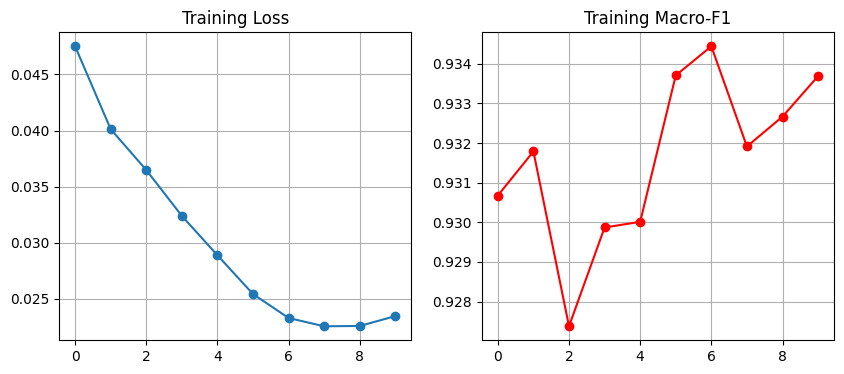

In [120]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(losses, marker='o')
plt.title("Training Loss")
plt.grid()

plt.subplot(1,2,2)
plt.plot(f1s, marker='o', color='red')
plt.title("Training Macro-F1")
plt.grid()
plt.show()